## G-42 or G-max

In [1]:
import sys
import math
from rdkit import Chem
from rdkit.Chem import AllChem

def get_v_w(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"SMILES Error: {smiles}")
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    return AllChem.ComputeMolVolume(mol) * 0.602214

PACKING_COEFFICIENT = 0.681
C0 = 2.4
Q = 0.42
rho_solution = 1.004
C_out = 0.154

M_na = 22.99
M_cl = 35.45

monomers = {
    'HEA':  {'M': 116.12, 'f': 14/101,  'smiles': 'C=CC(=O)OCCO'},
    'BA':   {'M': 128.17, 'f': 59/101,  'smiles': 'C=CC(=O)OCCCC'},
    'CBEA': {'M': 144.12, 'f': 8/101,   'smiles': 'C=CC(=O)OCCC(=O)[O-]'},
    'ATAC': {'M': 193.67, 'f': 10/101,  'smiles': 'C=CC(=O)OCC[N+](C)(C)C.[Cl-]'},
    'PEA':  {'M': 192.21, 'f': 10/101,  'smiles': 'C=CC(=O)OCCOc1ccccc1'},
}

if not abs(sum(p['f'] for p in monomers.values()) - 1.0) < 1e-4:
    sys.exit("Error: Molar fractions do not sum up to 1.0")

for name, p in monomers.items():
    p['V_w'] = get_v_w(p['smiles'])
    p['rho_pure'] = p['M'] / (p['V_w'] / PACKING_COEFFICIENT)

M_avg = sum(p['f'] * p['M'] for p in monomers.values())
V_w_avg = sum(p['f'] * p['V_w'] for p in monomers.values())

rho_pol = M_avg / (V_w_avg / PACKING_COEFFICIENT)

m_pol = C0 * M_avg
V_pol = m_pol / rho_pol
V_gel = 1000 * Q

phi_V = V_pol / V_gel
V_water = V_gel - V_pol
V_liquid_L = V_water / 1000.0

f_cbea = monomers['CBEA']['f']
f_atac = monomers['ATAC']['f']

c_fix_pos = (C0 * f_atac) / V_liquid_L
c_fix_neg = (C0 * f_cbea) / V_liquid_L
c_structural_cl = c_fix_pos

c_net = c_fix_pos - c_fix_neg

D = c_net**2 + 4 * (C_out**2)
C_na_in = (-c_net + math.sqrt(D)) / 2.0
C_cl_in = C_na_in + c_net

n_na_free = C_na_in * V_liquid_L
n_cl_total = C_cl_in * V_liquid_L

m_Na_total = n_na_free * M_na
m_Cl_total = n_cl_total * M_cl
m_ions_total = m_Na_total + m_Cl_total

V_w_na = get_v_w('[Na+]')
V_w_cl = get_v_w('[Cl-]')
V_w_salt_total = (n_na_free * V_w_na) + (n_cl_total * V_w_cl)

m_water = V_water * rho_solution
m_gel = m_pol + m_water

omega_m = m_pol / m_gel
omega_Na = m_Na_total / m_gel
omega_Cl = m_Cl_total / m_gel
omega_salt = m_ions_total / m_gel
swelling = m_water / m_pol

print("--- Individual Monomer Dry Densities (25 °C) ---")
for name, p in monomers.items():
    print(f"{name:<6} | M: {p['M']:>6.2f} g/mol | V_w: {p['V_w']:>6.2f} cm³/mol | rho: {p['rho_pure']:.4f} g/cm³")
print()

print("--- Copolymer Physical Properties (25 °C) ---")
print(f"Packing Coefficient (K):        {PACKING_COEFFICIENT}")
print(f"Mean Molar Mass (M_avg):        {M_avg:.2f} g/mol")
print(f"Copolymer Dry Density (rho_p):  {rho_pol:.4f} g/cm³\n")

print("--- Donnan Equilibrium (Full Dissociation Model) ---")
print(f"External Bath Concentration (C_out):     {C_out:.4f} M")
print(f"Structural Cl- Background Conc:          {c_structural_cl:.4f} M")
print(f"Net Fixed Network Charge Conc (c_net):   {c_net:+.4f} M")
print(f"Equilibrium Internal Na+ Conc:           {C_na_in:.4f} M")
print(f"Equilibrium Internal Total Cl- Conc:     {C_cl_in:.4f} M\n")

print("--- Total Ion Mass & Fractions (Global Balance) ---")
print(f"Total Na+ Mass in Gel Volume:   {m_Na_total:.4f} g")
print(f"Total Cl- Mass in Gel Volume:   {m_Cl_total:.4f} g")
print(f"Combined Total Ion Mass:        {m_ions_total:.4f} g")
print(f"Total Ion VdW Volume in Gel:    {V_w_salt_total:.4f} cm³\n")

print("--- Swollen Hydrogel Network Parameters ---")
print(f"Polymer Mass Concentration (m_p): {m_pol:.2f} g/L")
print(f"Polymer Volume Fraction (phi_V):  {phi_V:.4f} ({phi_V*100:.2f}%)")
print(f"Polymer Mass Fraction (omega_m):  {omega_m:.4f} ({omega_m*100:.2f}%)")
print(f"Total Na+ Mass Fraction (w_Na):   {omega_Na:.5f} ({omega_Na*100:.3f}%)")
print(f"Total Cl- Mass Fraction (w_Cl):   {omega_Cl:.5f} ({omega_Cl*100:.3f}%)")
print(f"Total Ion Mass Fraction (w_sum):  {omega_salt:.5f} ({omega_salt*100:.3f}%)")
print(f"Equilibrium Swelling Ratio (SR): {swelling:.3f} g solution/g polymer")


--- Individual Monomer Dry Densities (25 °C) ---
HEA    | M: 116.12 g/mol | V_w:  66.77 cm³/mol | rho: 1.1844 g/cm³
BA     | M: 128.17 g/mol | V_w:  81.27 cm³/mol | rho: 1.0739 g/cm³
CBEA   | M: 144.12 g/mol | V_w:  77.04 cm³/mol | rho: 1.2740 g/cm³
ATAC   | M: 193.67 g/mol | V_w: 101.97 cm³/mol | rho: 1.2935 g/cm³
PEA    | M: 192.21 g/mol | V_w: 109.90 cm³/mol | rho: 1.1910 g/cm³

--- Copolymer Physical Properties (25 °C) ---
Packing Coefficient (K):        0.681
Mean Molar Mass (M_avg):        140.59 g/mol
Copolymer Dry Density (rho_p):  1.1423 g/cm³

--- Donnan Equilibrium (Full Dissociation Model) ---
External Bath Concentration (C_out):     0.1540 M
Structural Cl- Background Conc:          1.9067 M
Net Fixed Network Charge Conc (c_net):   +0.3813 M
Equilibrium Internal Na+ Conc:           0.0544 M
Equilibrium Internal Total Cl- Conc:     0.4358 M

--- Total Ion Mass & Fractions (Global Balance) ---
Total Na+ Mass in Gel Volume:   0.1559 g
Total Cl- Mass in Gel Volume:   1.9252 g
C

In [2]:
Lx, Ly, Lz = 80.6296, 82.864, 80.0  # Å
V_cell_A3 = Lx * Ly * Lz
V_cell_cm3 = V_cell_A3 * 1e-24

V_pol_cell = phi_V * V_cell_cm3
m_pol_cell = V_pol_cell * rho_pol
n_monomers = m_pol_cell / M_avg
N_monomers = n_monomers * 6.022e23
V_liquid_cell = V_cell_cm3 - V_pol_cell
V_liquid_L = V_liquid_cell * 1e-3  
m_liquid_cell = V_liquid_cell * rho_solution
m_water_cell = m_liquid_cell
n_water = m_water_cell / 18.015
N_water = n_water * 6.022e23

n_Na = C_na_in * V_liquid_L
n_Cl = C_cl_in * V_liquid_L
N_Na = n_Na * 6.022e23
N_Cl = n_Cl * 6.022e23

print(f"\n--- Molecular counts in a cell of size {Lx}x{Ly}x{Lz} Å³ ---")
print(f"Total cell volume: {V_cell_A3:.2e} Å³ = {V_cell_cm3:.2e} cm³")
print(f"Number of monomer units: {N_monomers:.0f}")
print(f"Number of polymer units: {N_monomers/101:.0f}")
print(f"Number of water molecules: {N_water:.0f}")
print(f"Number of Na+ ions: {N_Na:.0f}")
print(f"Number of Cl- ions: {N_Cl:.0f}")


--- Molecular counts in a cell of size 80.6296x82.864x80.0 Å³ ---
Total cell volume: 5.35e+05 Å³ = 5.35e-19 cm³
Number of monomer units: 1839
Number of polymer units: 18
Number of water molecules: 5323
Number of Na+ ions: 5
Number of Cl- ions: 42


In [5]:
Lx, Ly, Lz = 80.6296, 82.864, 80.0
V_cell_A3 = Lx * Ly * Lz
V_cell_cm3 = V_cell_A3 * 1e-24

M_CH3 = 15.035
V_w_CH3 = 22.0
K = PACKING_COEFFICIENT

m_pol_frac = phi_V * V_cell_cm3 * rho_pol
N_monomers_frac = (m_pol_frac / M_avg) * 6.022e23
N_chains_frac = N_monomers_frac / 101.0
N_chains = max(1, round(N_chains_frac))

N_monomers = N_chains * 101
n_chains = N_chains / 6.022e23
n_monomers = N_monomers / 6.022e23

M_chain = 101 * M_avg + 2 * M_CH3
V_molar_chain = (101 * V_w_avg + 2 * V_w_CH3) / K

m_pol = n_chains * M_chain
V_pol = n_chains * V_molar_chain

V_liquid = V_cell_cm3 - V_pol
if V_liquid <= 0:
    raise ValueError("Cell too small for polymer volume")
V_liquid_L = V_liquid * 1e-3

n_fix_pos = n_monomers * monomers['ATAC']['f']
n_fix_neg = n_monomers * monomers['CBEA']['f']
c_fix_pos = n_fix_pos / V_liquid_L
c_fix_neg = n_fix_neg / V_liquid_L
c_net = c_fix_pos - c_fix_neg

D = c_net**2 + 4 * C_out**2
C_na_in = (-c_net + math.sqrt(D)) / 2.0
C_cl_in = C_na_in + c_net

n_Na = C_na_in * V_liquid_L
n_Cl = C_cl_in * V_liquid_L
N_Na = n_Na * 6.022e23
N_Cl = n_Cl * 6.022e23

m_Na = n_Na * M_na
m_Cl = n_Cl * M_cl
m_ions = m_Na + m_Cl

m_liquid = V_liquid * rho_solution
m_water = m_liquid - m_ions
if m_water < 0:
    m_water = 0.0
n_water = m_water / 18.015
N_water = n_water * 6.022e23

m_total = m_pol + m_liquid

rho_pol_eff = m_pol / V_pol
rho_pol_apparent = m_pol / V_cell_cm3
rho_gel = m_total / V_cell_cm3

smiles_no_ion = {
    'HEA': 'C=CC(=O)OCCO',
    'BA': 'C=CC(=O)OCCCC',
    'CBEA': 'C=CC(=O)OCCC(=O)[O-]',
    'ATAC': 'C=CC(=O)OCC[N+](C)(C)C',
    'PEA': 'C=CC(=O)OCCOc1ccccc1',
}

def get_atom_counts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    mol = Chem.AddHs(mol)
    counts = {}
    for atom in mol.GetAtoms():
        symb = atom.GetSymbol()
        counts[symb] = counts.get(symb, 0) + 1
    return counts

atom_counts_polymer = {}
for name, sm in smiles_no_ion.items():
    n_units = N_monomers * monomers[name]['f']
    for elem, cnt in get_atom_counts(sm).items():
        atom_counts_polymer[elem] = atom_counts_polymer.get(elem, 0) + cnt * n_units

atom_counts_polymer['C'] = atom_counts_polymer.get('C', 0) + 2 * N_chains
atom_counts_polymer['H'] = atom_counts_polymer.get('H', 0) + 6 * N_chains

atom_counts_total = atom_counts_polymer.copy()
atom_counts_total['H'] = atom_counts_total.get('H', 0) + 2 * N_water
atom_counts_total['O'] = atom_counts_total.get('O', 0) + N_water
atom_counts_total['Na'] = atom_counts_total.get('Na', 0) + N_Na
atom_counts_total['Cl'] = atom_counts_total.get('Cl', 0) + N_Cl

total_atoms_polymer = sum(atom_counts_polymer.values())
total_atoms_system = sum(atom_counts_total.values())

print("\n--- Cell-specific results (chain rounding + end groups) ---")
print(f"Cell: {Lx:.4f} x {Ly:.4f} x {Lz:.4f} A, V = {V_cell_A3:.3e} A^3 = {V_cell_cm3:.3e} cm^3")
print(f"Chains: {N_chains}, monomers: {N_monomers}")
print(f"Polymer volume: {V_pol:.4e} cm^3, liquid volume: {V_liquid:.4e} cm^3")

print("\n--- Densities ---")
print(f"Dry polymer (with end groups): {rho_pol_eff:.4f} g/cm^3")
print(f"Apparent polymer (mass/cell): {rho_pol_apparent} g/cm^3")
print(f"Hydrogel (total/cell): {rho_gel:.4f} g/cm^3")

print("\n--- Molecular counts ---")
print(f"Water: {N_water:.0f}, Na+: {N_Na:.0f}, Cl-: {N_Cl:.0f}")

print("\n--- Polymer atomic composition ---")
for elem, cnt in sorted(atom_counts_polymer.items()):
    print(f"  {elem}: {cnt:.0f}")

print("\n--- Total system atomic composition ---")
for elem, cnt in sorted(atom_counts_total.items()):
    print(f"  {elem}: {cnt:.0f}")

print(f"\nTotal atoms: polymer = {total_atoms_polymer:.0f}, system = {total_atoms_system:.0f}")


--- Cell-specific results (chain rounding + end groups) ---
Cell: 80.6296 x 82.8640 x 80.0000 A, V = 5.345e+05 A^3 = 5.345e-19 cm^3
Chains: 18, monomers: 1818
Polymer volume: 3.7348e-19 cm^3, liquid volume: 1.6103e-19 cm^3

--- Densities ---
Dry polymer (with end groups): 1.1388 g/cm^3
Apparent polymer (mass/cell): 0.7957419041068925 g/cm^3
Hydrogel (total/cell): 1.0982 g/cm^3

--- Molecular counts ---
Water: 5316, Na+: 5, Cl-: 41

--- Polymer atomic composition ---
  C: 13014
  H: 20916
  N: 180
  O: 4356

--- Total system atomic composition ---
  C: 13014
  Cl: 41
  H: 31548
  N: 180
  Na: 5
  O: 9672

Total atoms: polymer = 38466, system = 54461


## Saline

In [8]:
x, y, z = 80.6296, 82.864, 50.0

V_A3 = x * y * z
V_cm3 = V_A3 * 1e-24
V_L = V_cm3 * 1e-3

M_Na = 22.990
M_Cl = 35.453
M_H2O = 18.015
rho_solution = 1.004
C_NaCl = 0.154
NA = 6.022e23

n_NaCl = C_NaCl * V_L
m_NaCl = n_NaCl * (M_Na + M_Cl)
m_solution = V_cm3 * rho_solution
m_water = m_solution - m_NaCl
n_water = m_water / M_H2O

N_Na = n_NaCl * NA
N_Cl = n_NaCl * NA
N_water = n_water * NA

N_H = 2 * N_water
N_O = N_water

total_atoms = N_Na + N_Cl + N_H + N_O
rho_calc = m_solution / V_cm3

print(f"Volume = {V_A3:.3e} A^3 = {V_cm3:.3e} cm^3 = {V_L:.3e} L")
print(f"Na+ : {N_Na:.0f}")
print(f"Cl- : {N_Cl:.0f}")
print(f"H2O : {N_water:.0f}")
print(f"Atoms: Na={N_Na:.0f}, Cl={N_Cl:.0f}, H={N_H:.0f}, O={N_O:.0f}")
print(f"Total atoms = {total_atoms:.0f}")
print(f"Density = {rho_calc} g/cm^3 (expected {rho_solution})")

Volume = 3.341e+05 A^3 = 3.341e-19 cm^3 = 3.341e-22 L
Na+ : 31
Cl- : 31
H2O : 11111
Atoms: Na=31, Cl=31, H=22222, O=11111
Total atoms = 33395
Density = 1.004 g/cm^3 (expected 1.004)


## R1 - max

In [3]:
import sys
import math
from rdkit import Chem
from rdkit.Chem import AllChem

def get_v_w(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"SMILES Error: {smiles}")
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    return AllChem.ComputeMolVolume(mol) * 0.602214

PACKING_COEFFICIENT = 0.681
C0 = 2.4
Q = 0.51
rho_solution = 1.004
C_out = 0.154

M_na = 22.99
M_cl = 35.45

monomers = {
    'HEA':  {'M': 116.12, 'f': 0/101,  'smiles': 'C=CC(=O)OCCO'},
    'BA':   {'M': 128.17, 'f': 59/101,  'smiles': 'C=CC(=O)OCCCC'},
    'CBEA': {'M': 144.12, 'f': 0/101,   'smiles': 'C=CC(=O)OCCC(=O)[O-]'},
    'ATAC': {'M': 193.67, 'f': 10/101,  'smiles': 'C=CC(=O)OCC[N+](C)(C)C.[Cl-]'},
    'PEA':  {'M': 192.21, 'f': 32/101,  'smiles': 'C=CC(=O)OCCOc1ccccc1'},
}

if not abs(sum(p['f'] for p in monomers.values()) - 1.0) < 1e-4:
    sys.exit("Error: Molar fractions do not sum up to 1.0")

for name, p in monomers.items():
    p['V_w'] = get_v_w(p['smiles'])
    p['rho_pure'] = p['M'] / (p['V_w'] / PACKING_COEFFICIENT)

M_avg = sum(p['f'] * p['M'] for p in monomers.values())
V_w_avg = sum(p['f'] * p['V_w'] for p in monomers.values())

rho_pol = M_avg / (V_w_avg / PACKING_COEFFICIENT)

m_pol = C0 * M_avg
V_pol = m_pol / rho_pol
V_gel = 1000 * Q

phi_V = V_pol / V_gel
V_water = V_gel - V_pol
V_liquid_L = V_water / 1000.0

f_cbea = monomers['CBEA']['f']
f_atac = monomers['ATAC']['f']

c_fix_pos = (C0 * f_atac) / V_liquid_L
c_fix_neg = (C0 * f_cbea) / V_liquid_L
c_structural_cl = c_fix_pos

c_net = c_fix_pos - c_fix_neg

D = c_net**2 + 4 * (C_out**2)
C_na_in = (-c_net + math.sqrt(D)) / 2.0
C_cl_in = C_na_in + c_net

n_na_free = C_na_in * V_liquid_L
n_cl_total = C_cl_in * V_liquid_L

m_Na_total = n_na_free * M_na
m_Cl_total = n_cl_total * M_cl
m_ions_total = m_Na_total + m_Cl_total

V_w_na = get_v_w('[Na+]')
V_w_cl = get_v_w('[Cl-]')
V_w_salt_total = (n_na_free * V_w_na) + (n_cl_total * V_w_cl)

m_water = V_water * rho_solution
m_gel = m_pol + m_water

omega_m = m_pol / m_gel
omega_Na = m_Na_total / m_gel
omega_Cl = m_Cl_total / m_gel
omega_salt = m_ions_total / m_gel
swelling = m_water / m_pol

print("--- Individual Monomer Dry Densities (25 °C) ---")
for name, p in monomers.items():
    print(f"{name:<6} | M: {p['M']:>6.2f} g/mol | V_w: {p['V_w']:>6.2f} cm³/mol | rho: {p['rho_pure']:.4f} g/cm³")
print()

print("--- Copolymer Physical Properties (25 °C) ---")
print(f"Packing Coefficient (K):        {PACKING_COEFFICIENT}")
print(f"Mean Molar Mass (M_avg):        {M_avg:.2f} g/mol")
print(f"Copolymer Dry Density (rho_p):  {rho_pol:.4f} g/cm³\n")

print("--- Donnan Equilibrium (Full Dissociation Model) ---")
print(f"External Bath Concentration (C_out):     {C_out:.4f} M")
print(f"Structural Cl- Background Conc:          {c_structural_cl:.4f} M")
print(f"Net Fixed Network Charge Conc (c_net):   {c_net:+.4f} M")
print(f"Equilibrium Internal Na+ Conc:           {C_na_in:.4f} M")
print(f"Equilibrium Internal Total Cl- Conc:     {C_cl_in:.4f} M\n")

print("--- Total Ion Mass & Fractions (Global Balance) ---")
print(f"Total Na+ Mass in Gel Volume:   {m_Na_total:.4f} g")
print(f"Total Cl- Mass in Gel Volume:   {m_Cl_total:.4f} g")
print(f"Combined Total Ion Mass:        {m_ions_total:.4f} g")
print(f"Total Ion VdW Volume in Gel:    {V_w_salt_total:.4f} cm³\n")

print("--- Swollen Hydrogel Network Parameters ---")
print(f"Polymer Mass Concentration (m_p): {m_pol:.2f} g/L")
print(f"Polymer Volume Fraction (phi_V):  {phi_V:.4f} ({phi_V*100:.2f}%)")
print(f"Polymer Mass Fraction (omega_m):  {omega_m:.4f} ({omega_m*100:.2f}%)")
print(f"Total Na+ Mass Fraction (w_Na):   {omega_Na:.5f} ({omega_Na*100:.3f}%)")
print(f"Total Cl- Mass Fraction (w_Cl):   {omega_Cl:.5f} ({omega_Cl*100:.3f}%)")
print(f"Total Ion Mass Fraction (w_sum):  {omega_salt:.5f} ({omega_salt*100:.3f}%)")
print(f"Equilibrium Swelling Ratio (SR): {swelling:.3f} g solution/g polymer")


--- Individual Monomer Dry Densities (25 °C) ---
HEA    | M: 116.12 g/mol | V_w:  66.69 cm³/mol | rho: 1.1857 g/cm³
BA     | M: 128.17 g/mol | V_w:  81.27 cm³/mol | rho: 1.0739 g/cm³
CBEA   | M: 144.12 g/mol | V_w:  77.04 cm³/mol | rho: 1.2740 g/cm³
ATAC   | M: 193.67 g/mol | V_w: 101.97 cm³/mol | rho: 1.2935 g/cm³
PEA    | M: 192.21 g/mol | V_w: 109.91 cm³/mol | rho: 1.1910 g/cm³

--- Copolymer Physical Properties (25 °C) ---
Packing Coefficient (K):        0.681
Mean Molar Mass (M_avg):        154.95 g/mol
Copolymer Dry Density (rho_p):  1.1420 g/cm³

--- Donnan Equilibrium (Full Dissociation Model) ---
External Bath Concentration (C_out):     0.1540 M
Structural Cl- Background Conc:          1.2888 M
Net Fixed Network Charge Conc (c_net):   +1.2888 M
Equilibrium Internal Na+ Conc:           0.0181 M
Equilibrium Internal Total Cl- Conc:     1.3069 M

--- Total Ion Mass & Fractions (Global Balance) ---
Total Na+ Mass in Gel Volume:   0.0769 g
Total Cl- Mass in Gel Volume:   8.5424 g
C

In [9]:
Lx, Ly, Lz = 80.6296, 82.864, 80.0  # Å
V_cell_A3 = Lx * Ly * Lz
V_cell_cm3 = V_cell_A3 * 1e-24

V_pol_cell = phi_V * V_cell_cm3
m_pol_cell = V_pol_cell * rho_pol
n_monomers = m_pol_cell / M_avg
N_monomers = n_monomers * 6.022e23
V_liquid_cell = V_cell_cm3 - V_pol_cell
V_liquid_L = V_liquid_cell * 1e-3  
m_liquid_cell = V_liquid_cell * rho_solution
m_water_cell = m_liquid_cell
n_water = m_water_cell / 18.015
N_water = n_water * 6.022e23

n_Na = C_na_in * V_liquid_L
n_Cl = C_cl_in * V_liquid_L
N_Na = n_Na * 6.022e23
N_Cl = n_Cl * 6.022e23

print(f"\n--- Molecular counts in a cell of size {Lx}x{Ly}x{Lz} Å³ ---")
print(f"Total cell volume: {V_cell_A3:.2e} Å³ = {V_cell_cm3:.2e} cm³")
print(f"Number of monomer units: {N_monomers:.0f}")
print(f"Number of polymer units: {N_monomers/101:.0f}")
print(f"Number of water molecules: {N_water:.0f}")
print(f"Number of Na+ ions: {N_Na:.0f}")
print(f"Number of Cl- ions: {N_Cl:.0f}")


--- Molecular counts in a cell of size 80.6296x82.864x80.0 Å³ ---
Total cell volume: 5.35e+05 Å³ = 5.35e-19 cm³
Number of monomer units: 1515
Number of polymer units: 15
Number of water molecules: 6485
Number of Na+ ions: 2
Number of Cl- ions: 153


In [4]:
Lx, Ly, Lz = 80.6296, 82.864, 80.0
V_cell_A3 = Lx * Ly * Lz
V_cell_cm3 = V_cell_A3 * 1e-24

M_CH3 = 15.035
V_w_CH3 = 22.0
K = PACKING_COEFFICIENT

m_pol_frac = phi_V * V_cell_cm3 * rho_pol
N_monomers_frac = (m_pol_frac / M_avg) * 6.022e23
N_chains_frac = N_monomers_frac / 101.0
N_chains = max(1, round(N_chains_frac))

N_monomers = N_chains * 101
n_chains = N_chains / 6.022e23
n_monomers = N_monomers / 6.022e23

M_chain = 101 * M_avg + 2 * M_CH3
V_molar_chain = (101 * V_w_avg + 2 * V_w_CH3) / K

m_pol = n_chains * M_chain
V_pol = n_chains * V_molar_chain

V_liquid = V_cell_cm3 - V_pol
if V_liquid <= 0:
    raise ValueError("Cell too small for polymer volume")
V_liquid_L = V_liquid * 1e-3

n_fix_pos = n_monomers * monomers['ATAC']['f']
n_fix_neg = n_monomers * monomers['CBEA']['f']
c_fix_pos = n_fix_pos / V_liquid_L
c_fix_neg = n_fix_neg / V_liquid_L
c_net = c_fix_pos - c_fix_neg

D = c_net**2 + 4 * C_out**2
C_na_in = (-c_net + math.sqrt(D)) / 2.0
C_cl_in = C_na_in + c_net

n_Na = C_na_in * V_liquid_L
n_Cl = C_cl_in * V_liquid_L
N_Na = n_Na * 6.022e23
N_Cl = n_Cl * 6.022e23

m_Na = n_Na * M_na
m_Cl = n_Cl * M_cl
m_ions = m_Na + m_Cl

m_liquid = V_liquid * rho_solution
m_water = m_liquid - m_ions
if m_water < 0:
    m_water = 0.0
n_water = m_water / 18.015
N_water = n_water * 6.022e23

m_total = m_pol + m_liquid

rho_pol_eff = m_pol / V_pol
rho_pol_apparent = m_pol / V_cell_cm3
rho_gel = m_total / V_cell_cm3

smiles_no_ion = {
    'HEA': 'C=CC(=O)OCCO',
    'BA': 'C=CC(=O)OCCCC',
    'CBEA': 'C=CC(=O)OCCC(=O)[O-]',
    'ATAC': 'C=CC(=O)OCC[N+](C)(C)C',
    'PEA': 'C=CC(=O)OCCOc1ccccc1',
}

def get_atom_counts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    mol = Chem.AddHs(mol)
    counts = {}
    for atom in mol.GetAtoms():
        symb = atom.GetSymbol()
        counts[symb] = counts.get(symb, 0) + 1
    return counts

atom_counts_polymer = {}
for name, sm in smiles_no_ion.items():
    n_units = N_monomers * monomers[name]['f']
    for elem, cnt in get_atom_counts(sm).items():
        atom_counts_polymer[elem] = atom_counts_polymer.get(elem, 0) + cnt * n_units

atom_counts_polymer['C'] = atom_counts_polymer.get('C', 0) + 2 * N_chains
atom_counts_polymer['H'] = atom_counts_polymer.get('H', 0) + 6 * N_chains

atom_counts_total = atom_counts_polymer.copy()
atom_counts_total['H'] = atom_counts_total.get('H', 0) + 2 * N_water
atom_counts_total['O'] = atom_counts_total.get('O', 0) + N_water
atom_counts_total['Na'] = atom_counts_total.get('Na', 0) + N_Na
atom_counts_total['Cl'] = atom_counts_total.get('Cl', 0) + N_Cl

total_atoms_polymer = sum(atom_counts_polymer.values())
total_atoms_system = sum(atom_counts_total.values())

print("\n--- Cell-specific results (chain rounding + end groups) ---")
print(f"Cell: {Lx:.4f} x {Ly:.4f} x {Lz:.4f} A, V = {V_cell_A3:.3e} A^3 = {V_cell_cm3:.3e} cm^3")
print(f"Chains: {N_chains}, monomers: {N_monomers}")
print(f"Polymer volume: {V_pol:.4e} cm^3, liquid volume: {V_liquid:.4e} cm^3")

print("\n--- Densities ---")
print(f"Dry polymer (with end groups): {rho_pol_eff:.4f} g/cm^3")
print(f"Apparent polymer (mass/cell): {rho_pol_apparent} g/cm^3")
print(f"Hydrogel (total/cell): {rho_gel:.4f} g/cm^3")

print("\n--- Molecular counts ---")
print(f"Water: {N_water:.0f}, Na+: {N_Na:.0f}, Cl-: {N_Cl:.0f}")

print("\n--- Polymer atomic composition ---")
for elem, cnt in sorted(atom_counts_polymer.items()):
    print(f"  {elem}: {cnt:.0f}")

print("\n--- Total system atomic composition ---")
for elem, cnt in sorted(atom_counts_total.items()):
    print(f"  {elem}: {cnt:.0f}")

print(f"\nTotal atoms: polymer = {total_atoms_polymer:.0f}, system = {total_atoms_system:.0f}")


--- Cell-specific results (chain rounding + end groups) ---
Cell: 80.6296 x 82.8640 x 80.0000 A, V = 5.345e+05 A^3 = 5.345e-19 cm^3
Chains: 15, monomers: 1515
Polymer volume: 3.4294e-19 cm^3, liquid volume: 1.9157e-19 cm^3

--- Densities ---
Dry polymer (with end groups): 1.1389 g/cm^3
Apparent polymer (mass/cell): 0.7306895315591192 g/cm^3
Hydrogel (total/cell): 1.0905 g/cm^3

--- Molecular counts ---
Water: 6127, Na+: 2, Cl-: 152

--- Polymer atomic composition ---
  C: 12705
  H: 18870
  N: 150
  O: 3510

--- Total system atomic composition ---
  C: 12705
  Cl: 152
  H: 31125
  N: 150
  Na: 2
  O: 9637

Total atoms: polymer = 35235, system = 53771


## Pred_Poly (CLSP1)

In [13]:
import sys
import math
from rdkit import Chem
from rdkit.Chem import AllChem

def get_v_w(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"SMILES Error: {smiles}")
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    return AllChem.ComputeMolVolume(mol) * 0.602214

PACKING_COEFFICIENT = 0.681
C0 = 2.4
Q = 0.51
rho_solution = 1.004
C_out = 0.154

M_na = 22.99
M_cl = 35.45

monomers = {
    'SBA':  {'M': 128.17, 'f':  0.1819,  'smiles': 'C=CC(=O)OC(C)CC'},
    'BA':   {'M': 128.17, 'f': 0.4734,  'smiles': 'C=CC(=O)OCCCC'},
    'BNA': {'M': 162.19, 'f': 0.2676,   'smiles': 'C=CC(=O)OCc1ccccc1'},
    'ATAC': {'M': 235.75, 'f': 0.077,  'smiles': 'C=CC(=O)OCC[N+](CC)(CC)CC.[Cl-]'},
    
}

if not abs(sum(p['f'] for p in monomers.values()) - 1.0) < 1e-4:
    sys.exit("Error: Molar fractions do not sum up to 1.0")

for name, p in monomers.items():
    p['V_w'] = get_v_w(p['smiles'])
    p['rho_pure'] = p['M'] / (p['V_w'] / PACKING_COEFFICIENT)

M_avg = sum(p['f'] * p['M'] for p in monomers.values())
V_w_avg = sum(p['f'] * p['V_w'] for p in monomers.values())

rho_pol = M_avg / (V_w_avg / PACKING_COEFFICIENT)

m_pol = C0 * M_avg
V_pol = m_pol / rho_pol
V_gel = 1000 * Q

phi_V = V_pol / V_gel
V_water = V_gel - V_pol
V_liquid_L = V_water / 1000.0

f_cbea = 0
f_atac = monomers['ATAC']['f']

c_fix_pos = (C0 * f_atac) / V_liquid_L
c_fix_neg = (C0 * f_cbea) / V_liquid_L
c_structural_cl = c_fix_pos

c_net = c_fix_pos - c_fix_neg

D = c_net**2 + 4 * (C_out**2)
C_na_in = (-c_net + math.sqrt(D)) / 2.0
C_cl_in = C_na_in + c_net

n_na_free = C_na_in * V_liquid_L
n_cl_total = C_cl_in * V_liquid_L

m_Na_total = n_na_free * M_na
m_Cl_total = n_cl_total * M_cl
m_ions_total = m_Na_total + m_Cl_total

V_w_na = get_v_w('[Na+]')
V_w_cl = get_v_w('[Cl-]')
V_w_salt_total = (n_na_free * V_w_na) + (n_cl_total * V_w_cl)

m_water = V_water * rho_solution
m_gel = m_pol + m_water

omega_m = m_pol / m_gel
omega_Na = m_Na_total / m_gel
omega_Cl = m_Cl_total / m_gel
omega_salt = m_ions_total / m_gel
swelling = m_water / m_pol

print("--- Individual Monomer Dry Densities (25 °C) ---")
for name, p in monomers.items():
    print(f"{name:<6} | M: {p['M']:>6.2f} g/mol | V_w: {p['V_w']:>6.2f} cm³/mol | rho: {p['rho_pure']:.4f} g/cm³")
print()

print("--- Copolymer Physical Properties (25 °C) ---")
print(f"Packing Coefficient (K):        {PACKING_COEFFICIENT}")
print(f"Mean Molar Mass (M_avg):        {M_avg:.2f} g/mol")
print(f"Copolymer Dry Density (rho_p):  {rho_pol:.4f} g/cm³\n")

print("--- Donnan Equilibrium (Full Dissociation Model) ---")
print(f"External Bath Concentration (C_out):     {C_out:.4f} M")
print(f"Structural Cl- Background Conc:          {c_structural_cl:.4f} M")
print(f"Net Fixed Network Charge Conc (c_net):   {c_net:+.4f} M")
print(f"Equilibrium Internal Na+ Conc:           {C_na_in:.4f} M")
print(f"Equilibrium Internal Total Cl- Conc:     {C_cl_in:.4f} M\n")

print("--- Total Ion Mass & Fractions (Global Balance) ---")
print(f"Total Na+ Mass in Gel Volume:   {m_Na_total:.4f} g")
print(f"Total Cl- Mass in Gel Volume:   {m_Cl_total:.4f} g")
print(f"Combined Total Ion Mass:        {m_ions_total:.4f} g")
print(f"Total Ion VdW Volume in Gel:    {V_w_salt_total:.4f} cm³\n")

print("--- Swollen Hydrogel Network Parameters ---")
print(f"Polymer Mass Concentration (m_p): {m_pol:.2f} g/L")
print(f"Polymer Volume Fraction (phi_V):  {phi_V:.4f} ({phi_V*100:.2f}%)")
print(f"Polymer Mass Fraction (omega_m):  {omega_m:.4f} ({omega_m*100:.2f}%)")
print(f"Total Na+ Mass Fraction (w_Na):   {omega_Na:.5f} ({omega_Na*100:.3f}%)")
print(f"Total Cl- Mass Fraction (w_Cl):   {omega_Cl:.5f} ({omega_Cl*100:.3f}%)")
print(f"Total Ion Mass Fraction (w_sum):  {omega_salt:.5f} ({omega_salt*100:.3f}%)")
print(f"Equilibrium Swelling Ratio (SR): {swelling:.3f} g solution/g polymer")


--- Individual Monomer Dry Densities (25 °C) ---
SBA    | M: 128.17 g/mol | V_w:  81.50 cm³/mol | rho: 1.0710 g/cm³
BA     | M: 128.17 g/mol | V_w:  81.27 cm³/mol | rho: 1.0739 g/cm³
BNA    | M: 162.19 g/mol | V_w:  94.54 cm³/mol | rho: 1.1683 g/cm³
ATAC   | M: 235.75 g/mol | V_w: 131.56 cm³/mol | rho: 1.2203 g/cm³

--- Copolymer Physical Properties (25 °C) ---
Packing Coefficient (K):        0.681
Mean Molar Mass (M_avg):        145.54 g/mol
Copolymer Dry Density (rho_p):  1.1171 g/cm³

--- Donnan Equilibrium (Full Dissociation Model) ---
External Bath Concentration (C_out):     0.1540 M
Structural Cl- Background Conc:          0.9366 M
Net Fixed Network Charge Conc (c_net):   +0.9366 M
Equilibrium Internal Na+ Conc:           0.0247 M
Equilibrium Internal Total Cl- Conc:     0.9613 M

--- Total Ion Mass & Fractions (Global Balance) ---
Total Na+ Mass in Gel Volume:   0.1119 g
Total Cl- Mass in Gel Volume:   6.7237 g
Combined Total Ion Mass:        6.8356 g
Total Ion VdW Volume in Gel

In [14]:
Lx, Ly, Lz = 80.6296, 82.864, 80.0  # Å
V_cell_A3 = Lx * Ly * Lz
V_cell_cm3 = V_cell_A3 * 1e-24

V_pol_cell = phi_V * V_cell_cm3
m_pol_cell = V_pol_cell * rho_pol
n_monomers = m_pol_cell / M_avg
N_monomers = n_monomers * 6.022e23
V_liquid_cell = V_cell_cm3 - V_pol_cell
V_liquid_L = V_liquid_cell * 1e-3  
m_liquid_cell = V_liquid_cell * rho_solution
m_water_cell = m_liquid_cell
n_water = m_water_cell / 18.015
N_water = n_water * 6.022e23

n_Na = C_na_in * V_liquid_L
n_Cl = C_cl_in * V_liquid_L
N_Na = n_Na * 6.022e23
N_Cl = n_Cl * 6.022e23

print(f"\n--- Molecular counts in a cell of size {Lx}x{Ly}x{Lz} Å³ ---")
print(f"Total cell volume: {V_cell_A3:.2e} Å³ = {V_cell_cm3:.2e} cm³")
print(f"Number of monomer units: {N_monomers:.0f}")
print(f"Number of polymer units: {N_monomers/101:.0f}")
print(f"Number of water molecules: {N_water:.0f}")
print(f"Number of Na+ ions: {N_Na:.0f}")
print(f"Number of Cl- ions: {N_Cl:.0f}")


--- Molecular counts in a cell of size 80.6296x82.864x80.0 Å³ ---
Total cell volume: 5.35e+05 Å³ = 5.35e-19 cm³
Number of monomer units: 1515
Number of polymer units: 15
Number of water molecules: 6940
Number of Na+ ions: 3
Number of Cl- ions: 120


In [15]:
Lx, Ly, Lz = 80.6296, 82.864, 80.0
V_cell_A3 = Lx * Ly * Lz
V_cell_cm3 = V_cell_A3 * 1e-24

M_CH3 = 15.035
V_w_CH3 = 22.0
K = PACKING_COEFFICIENT

m_pol_frac = phi_V * V_cell_cm3 * rho_pol
N_monomers_frac = (m_pol_frac / M_avg) * 6.022e23
N_chains_frac = N_monomers_frac / 101.0
N_chains = max(1, round(N_chains_frac))

N_monomers = N_chains * 101
n_chains = N_chains / 6.022e23
n_monomers = N_monomers / 6.022e23

M_chain = 101 * M_avg + 2 * M_CH3
V_molar_chain = (101 * V_w_avg + 2 * V_w_CH3) / K

m_pol = n_chains * M_chain
V_pol = n_chains * V_molar_chain

V_liquid = V_cell_cm3 - V_pol
if V_liquid <= 0:
    raise ValueError("Cell too small for polymer volume")
V_liquid_L = V_liquid * 1e-3

n_fix_pos = n_monomers * monomers['ATAC']['f']
n_fix_neg = 0
c_fix_pos = n_fix_pos / V_liquid_L
c_fix_neg = n_fix_neg / V_liquid_L
c_net = c_fix_pos - c_fix_neg

D = c_net**2 + 4 * C_out**2
C_na_in = (-c_net + math.sqrt(D)) / 2.0
C_cl_in = C_na_in + c_net

n_Na = C_na_in * V_liquid_L
n_Cl = C_cl_in * V_liquid_L
N_Na = n_Na * 6.022e23
N_Cl = n_Cl * 6.022e23

m_Na = n_Na * M_na
m_Cl = n_Cl * M_cl
m_ions = m_Na + m_Cl

m_liquid = V_liquid * rho_solution
m_water = m_liquid - m_ions
if m_water < 0:
    m_water = 0.0
n_water = m_water / 18.015
N_water = n_water * 6.022e23

m_total = m_pol + m_liquid

rho_pol_eff = m_pol / V_pol
rho_pol_apparent = m_pol / V_cell_cm3
rho_gel = m_total / V_cell_cm3

smiles_no_ion = {
    'SBA':  'C=CC(=O)OC(C)CC',
    'BA':    'C=CC(=O)OCCCC',
    'BNA':  'C=CC(=O)OCc1ccccc1',
    'ATAC':  'C=CC(=O)OCC[N+](CC)(CC)CC',
}

def get_atom_counts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    mol = Chem.AddHs(mol)
    counts = {}
    for atom in mol.GetAtoms():
        symb = atom.GetSymbol()
        counts[symb] = counts.get(symb, 0) + 1
    return counts

atom_counts_polymer = {}
for name, sm in smiles_no_ion.items():
    n_units = N_monomers * monomers[name]['f']
    for elem, cnt in get_atom_counts(sm).items():
        atom_counts_polymer[elem] = atom_counts_polymer.get(elem, 0) + cnt * n_units

atom_counts_polymer['C'] = atom_counts_polymer.get('C', 0) + 2 * N_chains
atom_counts_polymer['H'] = atom_counts_polymer.get('H', 0) + 6 * N_chains

atom_counts_total = atom_counts_polymer.copy()
atom_counts_total['H'] = atom_counts_total.get('H', 0) + 2 * N_water
atom_counts_total['O'] = atom_counts_total.get('O', 0) + N_water
atom_counts_total['Na'] = atom_counts_total.get('Na', 0) + N_Na
atom_counts_total['Cl'] = atom_counts_total.get('Cl', 0) + N_Cl

total_atoms_polymer = sum(atom_counts_polymer.values())
total_atoms_system = sum(atom_counts_total.values())

print("\n--- Cell-specific results (chain rounding + end groups) ---")
print(f"Cell: {Lx:.4f} x {Ly:.4f} x {Lz:.4f} A, V = {V_cell_A3:.3e} A^3 = {V_cell_cm3:.3e} cm^3")
print(f"Chains: {N_chains}, monomers: {N_monomers}")
print(f"Polymer volume: {V_pol:.4e} cm^3, liquid volume: {V_liquid:.4e} cm^3")

print("\n--- Densities ---")
print(f"Dry polymer (with end groups): {rho_pol_eff:.4f} g/cm^3")
print(f"Apparent polymer (mass/cell): {rho_pol_apparent} g/cm^3")
print(f"Hydrogel (total/cell): {rho_gel:.4f} g/cm^3")

print("\n--- Molecular counts ---")
print(f"Water: {N_water:.0f}, Na+: {N_Na:.0f}, Cl-: {N_Cl:.0f}")

print("\n--- Polymer atomic composition ---")
for elem, cnt in sorted(atom_counts_polymer.items()):
    print(f"  {elem}: {cnt:.0f}")

print("\n--- Total system atomic composition ---")
for elem, cnt in sorted(atom_counts_total.items()):
    print(f"  {elem}: {cnt:.0f}")

print(f"\nTotal atoms: polymer = {total_atoms_polymer:.0f}, system = {total_atoms_system:.0f}")


--- Cell-specific results (chain rounding + end groups) ---
Cell: 80.6296 x 82.8640 x 80.0000 A, V = 5.345e+05 A^3 = 5.345e-19 cm^3
Chains: 15, monomers: 1515
Polymer volume: 3.2939e-19 cm^3, liquid volume: 2.0511e-19 cm^3

--- Densities ---
Dry polymer (with end groups): 1.1139 g/cm^3
Apparent polymer (mass/cell): 0.686443905190125 g/cm^3
Hydrogel (total/cell): 1.0717 g/cm^3

--- Molecular counts ---
Water: 6644, Na+: 3, Cl-: 120

--- Polymer atomic composition ---
  C: 12317
  H: 18624
  N: 117
  O: 3030

--- Total system atomic composition ---
  C: 12317
  Cl: 120
  H: 31913
  N: 117
  Na: 3
  O: 9674

Total atoms: polymer = 34087, system = 54143


## statistics

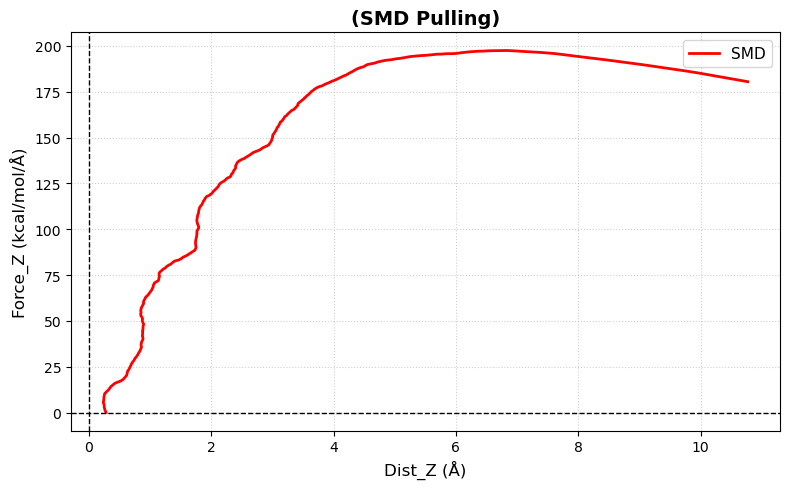

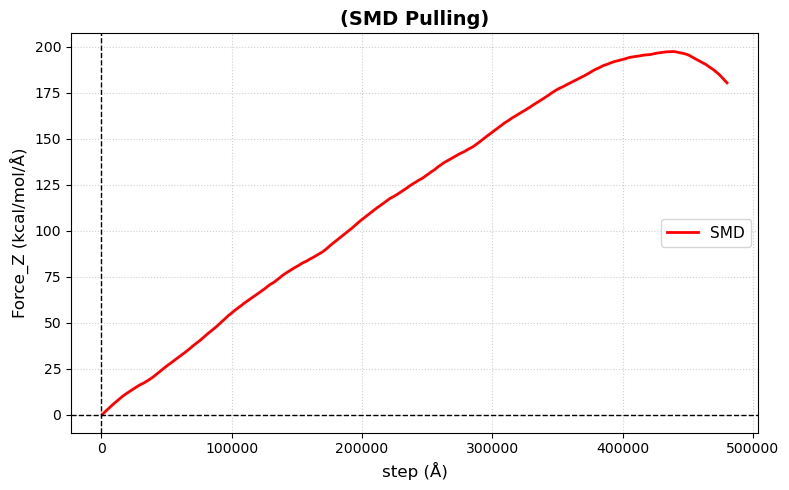

In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("adhesion_data_R1_1.txt", skiprows=1)

step = data[:, 0]
dist_z = data[:, 1]
force_z = data[:, 2]
dist_z -= 138
dist_z = -dist_z
step-=840300
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(dist_z, force_z, color="red", linewidth=2, label="SMD")

plt.title("(SMD Pulling)", fontsize=14, fontweight="bold")
plt.xlabel("Dist_Z (Å)", fontsize=12)
plt.ylabel("Force_Z (kcal/mol/Å)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(step, force_z, color="red", linewidth=2, label="SMD")
plt.title("(SMD Pulling)", fontsize=14, fontweight="bold")
plt.xlabel("step (Å)", fontsize=12)
plt.ylabel("Force_Z (kcal/mol/Å)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

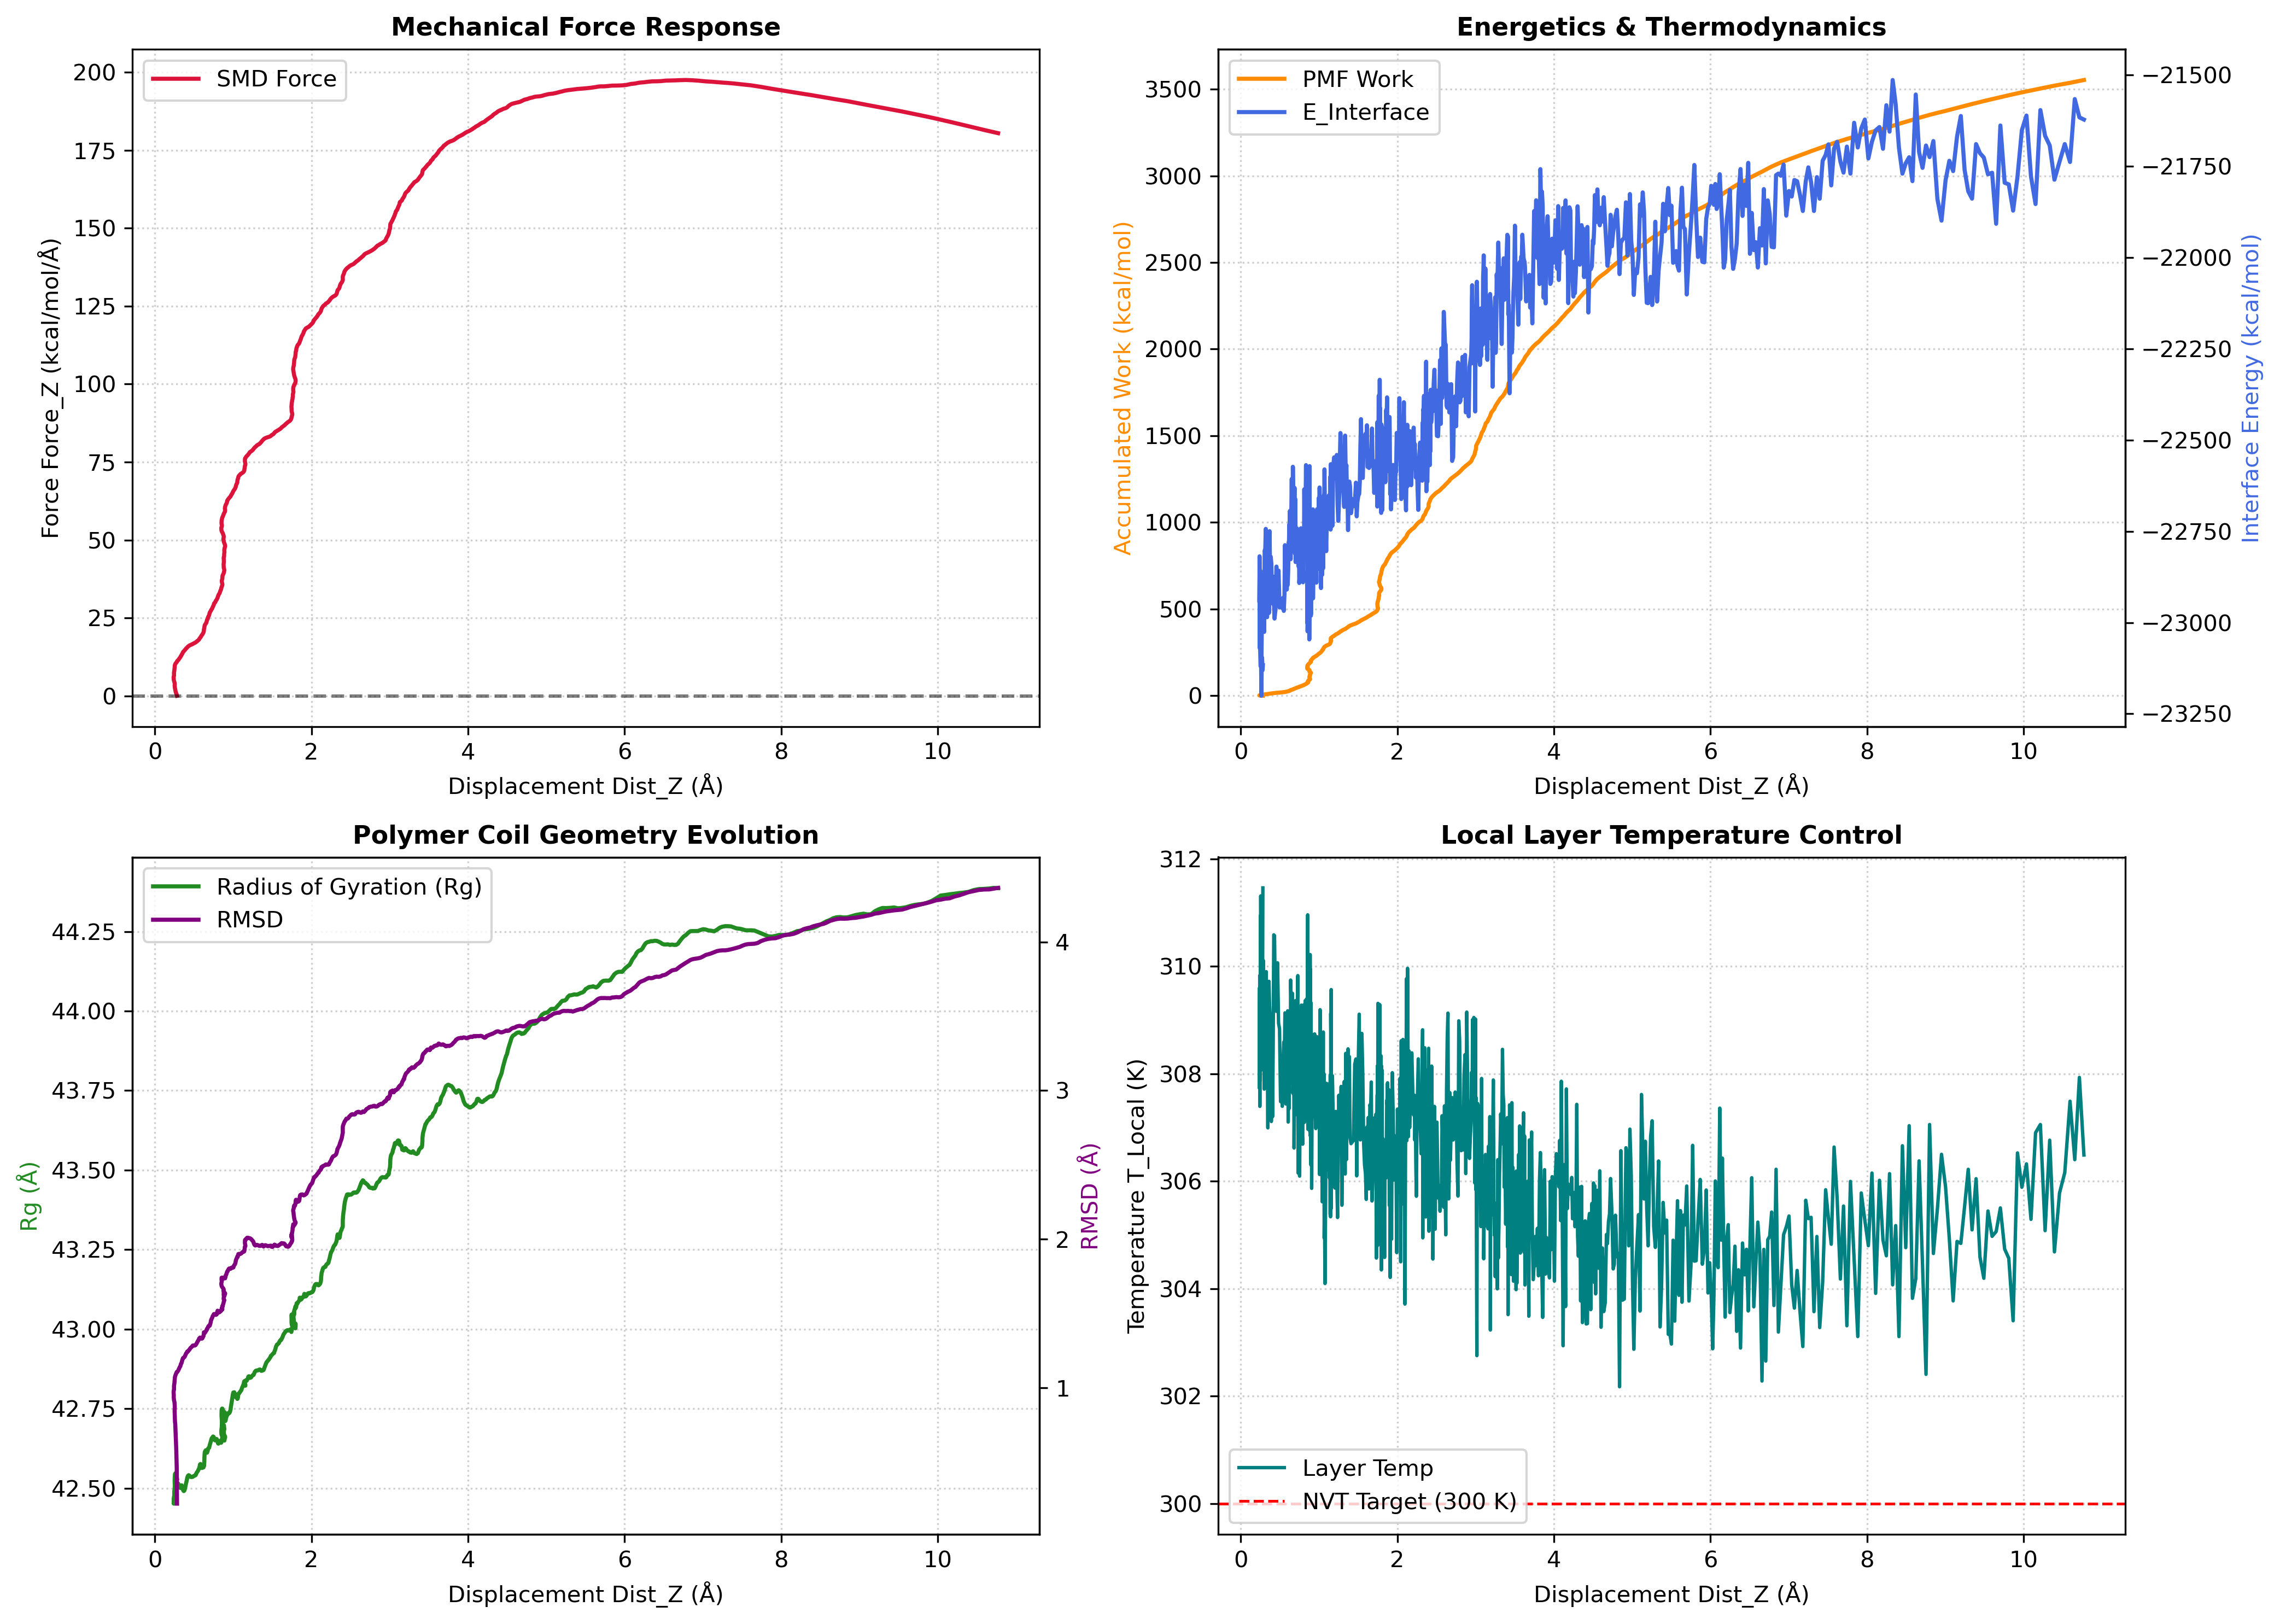

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 0=Step, 1=Dist_Z, 2=Force_Z, 3=PMF_Work, 4=Rg, 5=RMSD, 6=E_Interface, 7=E_Poly, 8=T_Local
try:
    data = np.loadtxt("adhesion_data_R1_1.txt", skiprows=1)
except IOError:
    print("Error: 'adhesion_data_R1_1.txt' not found in the current directory.")
    exit()

dist = data[:, 1]
dist -= 138
dist =-dist
force = data[:, 2]
work = data[:, 3]
rg = data[:, 4]
rmsd = data[:, 5]
e_int = data[:, 6]
t_local = data[:, 8]

fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})

axs[0, 0].plot(dist, force, color="crimson", linewidth=1.8, label="SMD Force")
axs[0, 0].set_title("Mechanical Force Response", fontsize=11, fontweight="bold")
axs[0, 0].set_xlabel("Displacement Dist_Z (Å)")
axs[0, 0].set_ylabel("Force Force_Z (kcal/mol/Å)")
axs[0, 0].axhline(0, color="black", linestyle="--", alpha=0.5)
axs[0, 0].grid(True, linestyle=":", alpha=0.6)
axs[0, 0].legend(loc="upper left")

ax2_twin = axs[0, 1].twinx()
p1, = axs[0, 1].plot(dist, work, color="darkorange", linewidth=1.8, label="PMF Work")
p2, = ax2_twin.plot(dist, e_int, color="royalblue", linewidth=1.8, label="E_Interface")
axs[0, 1].set_title("Energetics & Thermodynamics", fontsize=11, fontweight="bold")
axs[0, 1].set_xlabel("Displacement Dist_Z (Å)")
axs[0, 1].set_ylabel("Accumulated Work (kcal/mol)", color="darkorange")
ax2_twin.set_ylabel("Interface Energy (kcal/mol)", color="royalblue")
axs[0, 1].grid(True, linestyle=":", alpha=0.6)
axs[0, 1].legend(handles=[p1, p2], loc="upper left")

ax3_twin = axs[1, 0].twinx()
p3, = axs[1, 0].plot(dist, rg, color="forestgreen", linewidth=1.8, label="Radius of Gyration (Rg)")
p4, = ax3_twin.plot(dist, rmsd, color="purple", linewidth=1.8, label="RMSD")
axs[1, 0].set_title("Polymer Coil Geometry Evolution", fontsize=11, fontweight="bold")
axs[1, 0].set_xlabel("Displacement Dist_Z (Å)")
axs[1, 0].set_ylabel("Rg (Å)", color="forestgreen")
ax3_twin.set_ylabel("RMSD (Å)", color="purple")
axs[1, 0].grid(True, linestyle=":", alpha=0.6)
axs[1, 0].legend(handles=[p3, p4], loc="upper left")

axs[1, 1].plot(dist, t_local, color="teal", linewidth=1.5, label="Layer Temp")
axs[1, 1].set_title("Local Layer Temperature Control", fontsize=11, fontweight="bold")
axs[1, 1].set_xlabel("Displacement Dist_Z (Å)")
axs[1, 1].set_ylabel("Temperature T_Local (K)")
axs[1, 1].axhline(300.0, color="red", linestyle="--", linewidth=1.2, label="NVT Target (300 K)")
axs[1, 1].grid(True, linestyle=":", alpha=0.6)
axs[1, 1].legend(loc="lower left")

plt.tight_layout()
plt.savefig("smd_R1_0.00025_analysis.png", dpi=300)
plt.show()


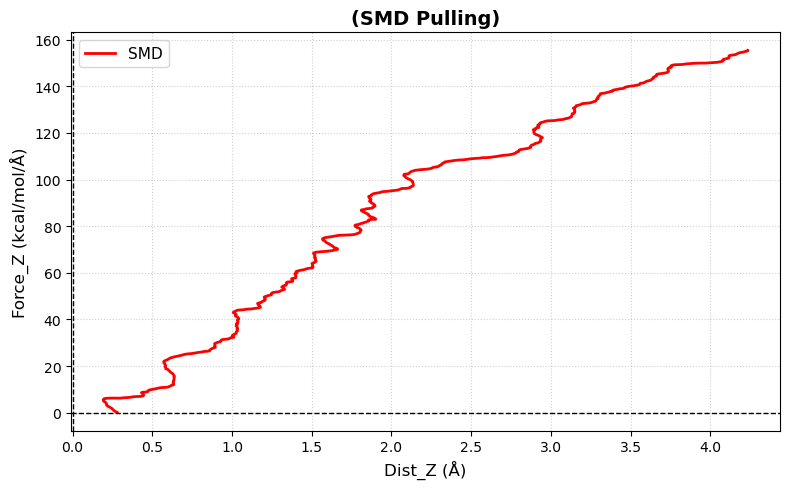

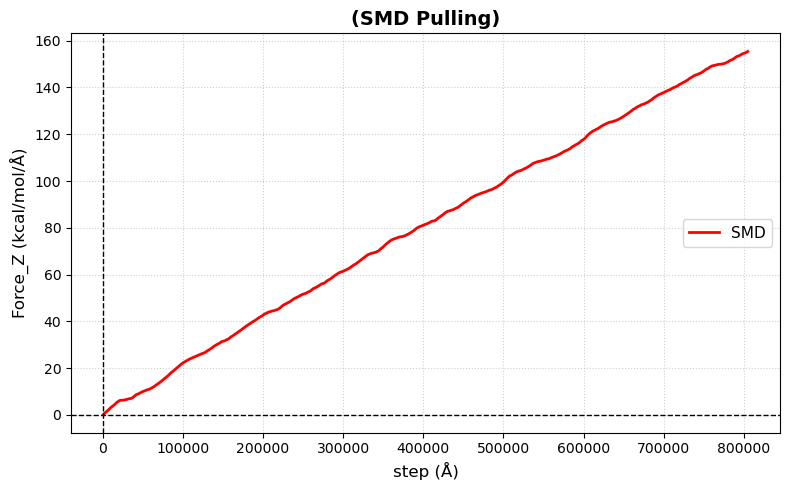

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("adhesion_data_R1_2.txt", skiprows=1)

step = data[:, 0]
dist_z = data[:, 1]
force_z = data[:, 2]
dist_z -= 138
dist_z = -dist_z
step-=840300
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(dist_z, force_z, color="red", linewidth=2, label="SMD")

plt.title("(SMD Pulling)", fontsize=14, fontweight="bold")
plt.xlabel("Dist_Z (Å)", fontsize=12)
plt.ylabel("Force_Z (kcal/mol/Å)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(step, force_z, color="red", linewidth=2, label="SMD")
plt.title("(SMD Pulling)", fontsize=14, fontweight="bold")
plt.xlabel("step (Å)", fontsize=12)
plt.ylabel("Force_Z (kcal/mol/Å)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

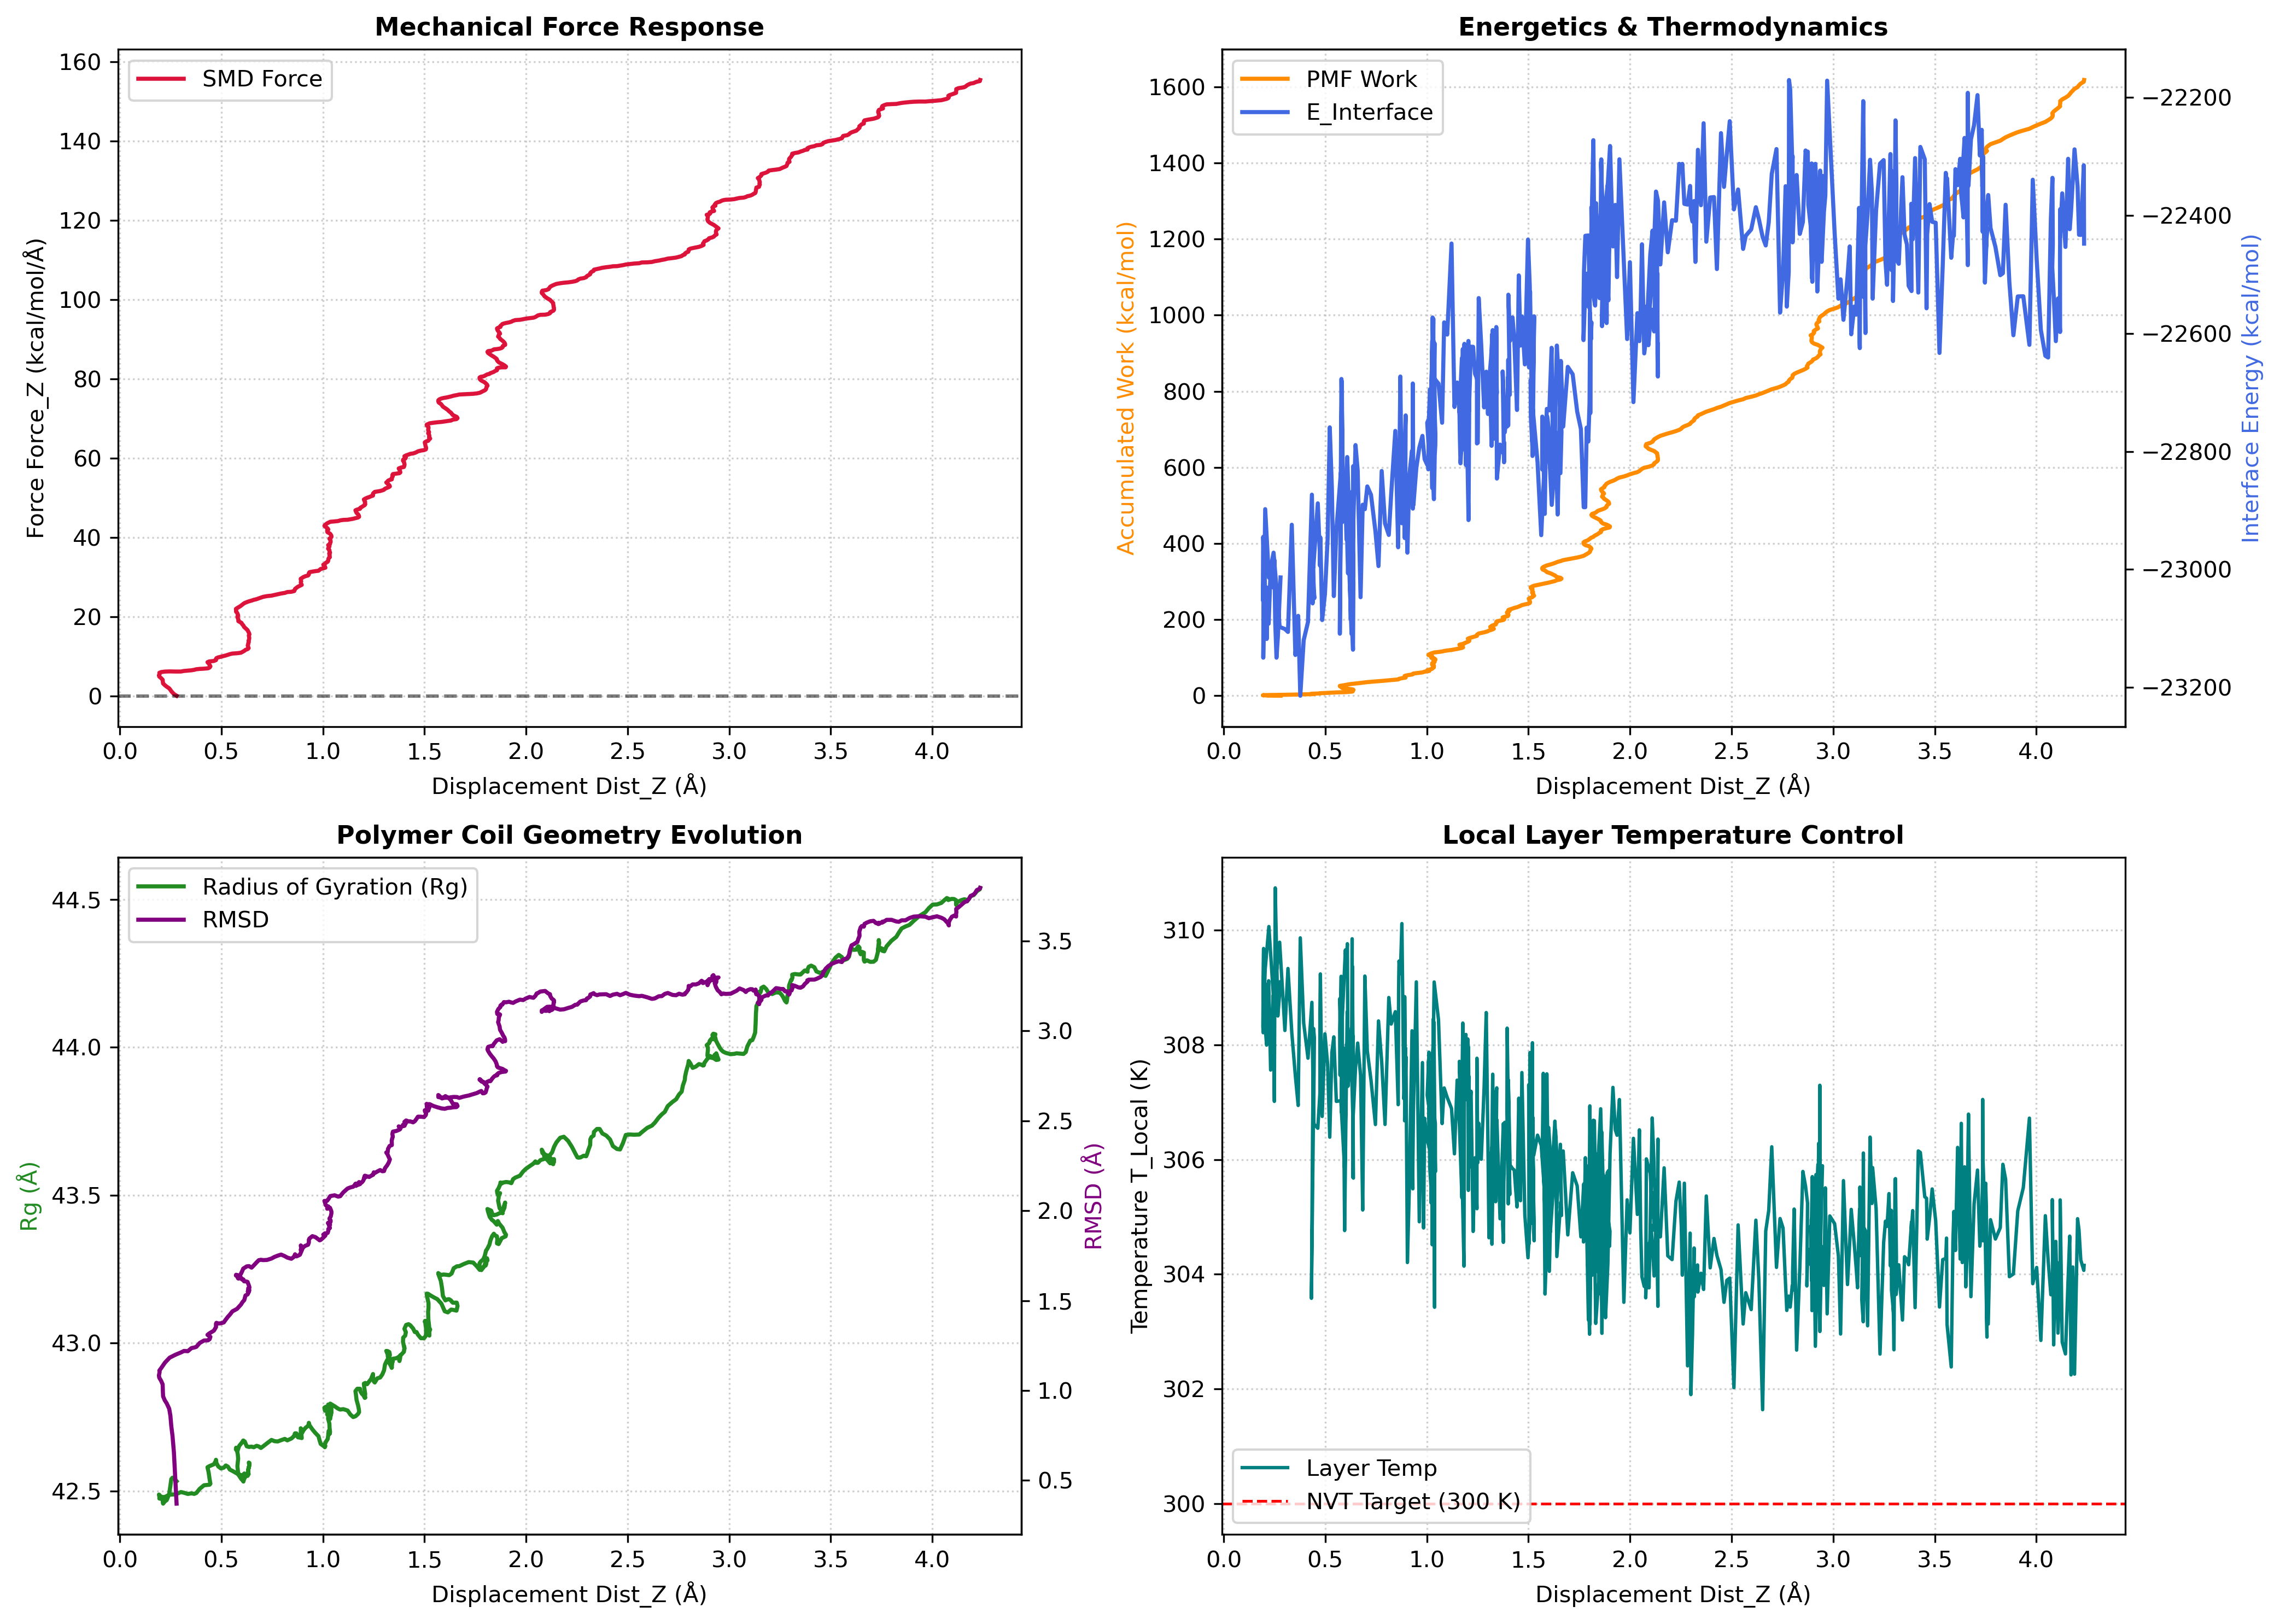

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 0=Step, 1=Dist_Z, 2=Force_Z, 3=PMF_Work, 4=Rg, 5=RMSD, 6=E_Interface, 7=E_Poly, 8=T_Local
try:
    data = np.loadtxt("adhesion_data_R1_2.txt", skiprows=1)
except IOError:
    print("Error: 'adhesion_data_R1_1.txt' not found in the current directory.")
    exit()

dist = data[:, 1]
dist -= 138
dist =-dist
force = data[:, 2]
work = data[:, 3]
rg = data[:, 4]
rmsd = data[:, 5]
e_int = data[:, 6]
t_local = data[:, 8]

fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})

axs[0, 0].plot(dist, force, color="crimson", linewidth=1.8, label="SMD Force")
axs[0, 0].set_title("Mechanical Force Response", fontsize=11, fontweight="bold")
axs[0, 0].set_xlabel("Displacement Dist_Z (Å)")
axs[0, 0].set_ylabel("Force Force_Z (kcal/mol/Å)")
axs[0, 0].axhline(0, color="black", linestyle="--", alpha=0.5)
axs[0, 0].grid(True, linestyle=":", alpha=0.6)
axs[0, 0].legend(loc="upper left")

ax2_twin = axs[0, 1].twinx()
p1, = axs[0, 1].plot(dist, work, color="darkorange", linewidth=1.8, label="PMF Work")
p2, = ax2_twin.plot(dist, e_int, color="royalblue", linewidth=1.8, label="E_Interface")
axs[0, 1].set_title("Energetics & Thermodynamics", fontsize=11, fontweight="bold")
axs[0, 1].set_xlabel("Displacement Dist_Z (Å)")
axs[0, 1].set_ylabel("Accumulated Work (kcal/mol)", color="darkorange")
ax2_twin.set_ylabel("Interface Energy (kcal/mol)", color="royalblue")
axs[0, 1].grid(True, linestyle=":", alpha=0.6)
axs[0, 1].legend(handles=[p1, p2], loc="upper left")

ax3_twin = axs[1, 0].twinx()
p3, = axs[1, 0].plot(dist, rg, color="forestgreen", linewidth=1.8, label="Radius of Gyration (Rg)")
p4, = ax3_twin.plot(dist, rmsd, color="purple", linewidth=1.8, label="RMSD")
axs[1, 0].set_title("Polymer Coil Geometry Evolution", fontsize=11, fontweight="bold")
axs[1, 0].set_xlabel("Displacement Dist_Z (Å)")
axs[1, 0].set_ylabel("Rg (Å)", color="forestgreen")
ax3_twin.set_ylabel("RMSD (Å)", color="purple")
axs[1, 0].grid(True, linestyle=":", alpha=0.6)
axs[1, 0].legend(handles=[p3, p4], loc="upper left")

axs[1, 1].plot(dist, t_local, color="teal", linewidth=1.5, label="Layer Temp")
axs[1, 1].set_title("Local Layer Temperature Control", fontsize=11, fontweight="bold")
axs[1, 1].set_xlabel("Displacement Dist_Z (Å)")
axs[1, 1].set_ylabel("Temperature T_Local (K)")
axs[1, 1].axhline(300.0, color="red", linestyle="--", linewidth=1.2, label="NVT Target (300 K)")
axs[1, 1].grid(True, linestyle=":", alpha=0.6)
axs[1, 1].legend(loc="lower left")

plt.tight_layout()
plt.savefig("smd_R1_0.0001_analysis.png", dpi=300)
plt.show()


## Dump cutoff

In [5]:
import sys, os, glob, py7zr

def thin_trajectory(input_path, output_path, stride=3):
    with open(input_path, 'r') as infile, open(output_path, 'w') as outfile:
        timestep_count = -1
        current_block = []
        for line in infile:
            if line.startswith("ITEM: TIMESTEP"):
                if timestep_count >= 0 and (timestep_count % stride == 0):
                    outfile.writelines(current_block)
                timestep_count += 1
                current_block = [line]
            else:
                current_block.append(line)
        if timestep_count >= 0 and (timestep_count % stride == 0):
            outfile.writelines(current_block)

if __name__ == "__main__":
    files = glob.glob("*.lammpstrj")
    if not files:
        sys.exit(1)
    filters = [{"id": py7zr.FILTER_LZMA2, "dict_size": 134217728}]
    for infile in files:
        base_name = os.path.splitext(infile)[0]
        tmp_file = f"{base_name}_thinned.tmp"
        sevenz_outfile = f"{base_name}_clean.7z"
        print(f"Processing: {infile}...")
        thin_trajectory(infile, tmp_file, stride=3)
        with py7zr.SevenZipFile(sevenz_outfile, 'w', filters=filters) as archive:
            archive.write(tmp_file, arcname=f"{base_name}_clean.lammpstrj")
        if os.path.exists(tmp_file):
            os.remove(tmp_file)
        old_size = os.path.getsize(infile) / (1024 * 1024)
        new_size = os.path.getsize(sevenz_outfile) / (1024 * 1024)
        print(f"Saved {sevenz_outfile} ({old_size:.1f} MB -> {new_size:.1f} MB)")


Processing: trajectory_smd_R1_2.lammpstrj...
Saved trajectory_smd_R1_2_clean.7z (393.0 MB -> 47.6 MB)
